# Nonlinear Cournot example: figures

This notebook reproduces the two panels used in the nonlinear-demand section.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("figures")
OUT.mkdir(exist_ok=True)

a = 4.0
beta = 1.0
c = 1.0

q_initial = np.array([0.2, 1.0], dtype=float)
qbar = np.array([5.0, 5.0], dtype=float)

# Main asymmetric profile for the convergence-rate experiment
bhat_main = np.array([0.6, 1.2], dtype=float)

sigma = 0.2
T = 5000
M = 5000
seed = 12345

def demand(Q):
    return a / (1.0 + beta * Q)

def abs_demand_slope(Q):
    return a * beta / (1.0 + beta * Q)**2

def aggregate_equilibrium(S):
    A = beta
    B = 1.0 + beta * c * S
    C = -S * (a - c)
    return (-B + np.sqrt(B**2 - 4.0*A*C)) / (2.0*A)

def equilibrium_from_bhat(bhat):
    bhat = np.asarray(bhat, dtype=float)
    S = np.sum(1.0 / bhat)
    Q_star = aggregate_equilibrium(S)
    q_star = Q_star / (S * bhat)
    return q_star, Q_star, S

def simulate_deterministic(bhat, q0, horizon):
    bhat = np.asarray(bhat, dtype=float)
    q = np.asarray(q0, dtype=float).copy()
    q_star, Q_star, _ = equilibrium_from_bhat(bhat)

    trajectory = np.empty((horizon + 1, len(q)))
    trajectory[0] = q

    for t in range(1, horizon + 1):
        p = demand(q.sum())
        q = np.clip(
            q + ((p - c) - bhat*q) / (bhat*t),
            0.0,
            qbar,
        )
        trajectory[t] = q

    weighted_error = np.sum(
        bhat * (trajectory - q_star)**2, axis=1
    )
    return trajectory, q_star, Q_star, weighted_error


## Panel (a): aggregate dynamics for different subjective slopes


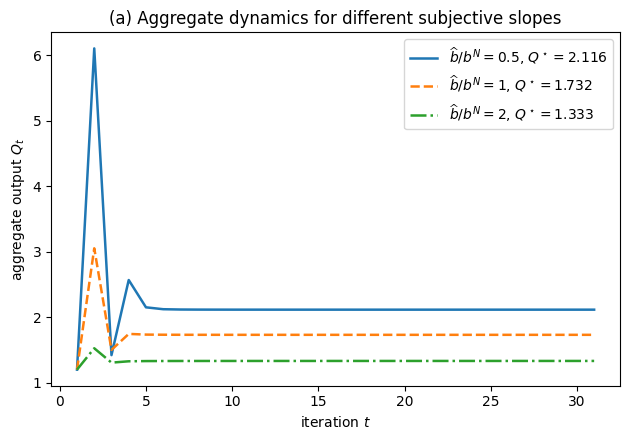

b^N = 0.535898384862


In [ ]:
Q_N = np.sqrt(3.0)
b_N = abs_demand_slope(Q_N)

horizon_a = 30

fig, ax = plt.subplots(figsize=(6.4, 4.5))

line_styles = {0.5: "-", 1.0: "--", 2.0: "-."}

for mult in [0.5, 1.0, 2.0]:
    bhat = mult * b_N
    tr, _, Q_star, _ = simulate_deterministic(
        np.array([bhat, bhat]), q_initial, horizon_a
    )
    ax.plot(
        np.arange(1, horizon_a + 2),
        tr.sum(axis=1),
        linestyle=line_styles[mult],
        linewidth=1.8,
        label=rf"$\widehat b/b^N={mult:g}$, $Q^\star={Q_star:.3f}$",
    )

ax.set_xlabel(r"iteration $t$")
ax.set_ylabel(r"aggregate output $Q_t$")
ax.set_title("(a) Aggregate dynamics for different subjective slopes")
ax.legend()
fig.tight_layout()

fig.savefig(OUT / "nonlinear_panel_a.pdf")
fig.savefig(OUT / "nonlinear_panel_a.png", dpi=600)
plt.show()

print(f"b^N = {b_N:.12f}")


## Panel (b): deterministic and stochastic convergence rates


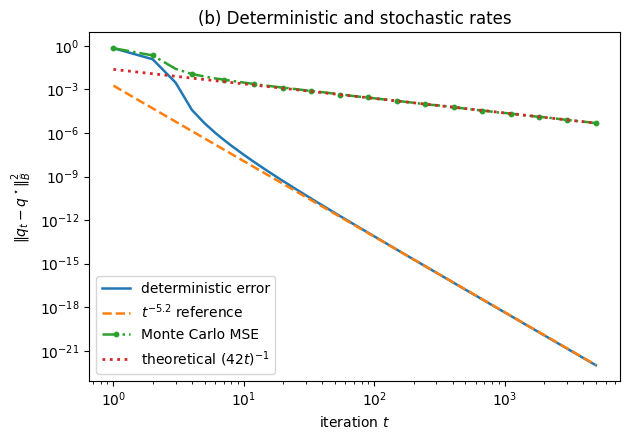

Q* = 1.500000000000
q* = [1.  0.5]
S = 2.500000000000
lambda = 2.600000000000
deterministic exponent = 5.200000000000
deterministic reference coefficient = 1.813109772373e-03
fitted deterministic slope = -5.208533
theoretical stochastic coefficient = 0.023809523810
1/42 = 0.023809523810
fitted stochastic slope = -0.997156
5000 * MSE_5000 = 0.02355221


In [ ]:
# Deterministic trajectory for the main asymmetric profile
traj, q_star, Q_star, det_error = simulate_deterministic(
    bhat_main, q_initial, T
)

S = np.sum(1.0 / bhat_main)
lam = 1.0 + S * abs_demand_slope(Q_star)
det_exponent = 2.0 * lam

# Monte Carlo estimate for the stochastic model
rng = np.random.default_rng(seed)
q = np.tile(q_initial, (M, 1))

mse = np.empty(T + 1)
mse[0] = np.mean(
    np.sum(bhat_main * (q - q_star)**2, axis=1)
)

for t in range(1, T + 1):
    Q = q.sum(axis=1)
    xi = sigma * rng.choice((-1.0, 1.0), size=M)
    observed_price = demand(Q) + xi

    q = np.clip(
        q + ((observed_price[:, None] - c) - bhat_main*q)
            / (bhat_main*t),
        0.0,
        qbar,
    )

    mse[t] = np.mean(
        np.sum(bhat_main * (q - q_star)**2, axis=1)
    )

tt = np.arange(1, T + 1)
# Indexing convention: array entry k corresponds to q_{k+1}.
# Hence times t=1,...,T are paired with entries 0,...,T-1.

# The deterministic theory predicts the exponent -5.2.
# The multiplicative constant is not derived, so the reference line
# is normalized to pass through the deterministic error at t = 200.
t_ref = 200
C_det = det_error[t_ref - 1] * t_ref**det_exponent
det_reference = C_det * tt**(-det_exponent)

# For the stochastic linearization, both exponent and coefficient
# are theoretically predicted.
C_noise = S * sigma**2 / (2.0*lam - 1.0)
noise_reference = C_noise / tt

fig, ax = plt.subplots(figsize=(6.4, 4.5))
ax.loglog(
    tt, det_error[:-1],
    linestyle="-", linewidth=1.8,
    label="deterministic error"
)
ax.loglog(
    tt, det_reference,
    linestyle="--", linewidth=1.8,
    label=rf"$t^{{-{det_exponent:.1f}}}$ reference"
)
marker_idx = np.unique(
    np.geomspace(1, T, 18).astype(int) - 1
)

ax.loglog(
    tt, mse[:-1],
    linestyle="-.", linewidth=1.8,
    marker="o", markersize=3.2,
    markevery=marker_idx,
    label="Monte Carlo MSE"
)
ax.loglog(
    tt, noise_reference,
    linestyle=":", linewidth=2.0,
    label=r"theoretical $(42t)^{-1}$"
)

ax.set_xlabel(r"iteration $t$")
ax.set_ylabel(r"$\|q_t-q^\star\|_{\widehat B}^2$")
ax.set_title("(b) Deterministic and stochastic rates")
ax.legend()
fig.tight_layout()

fig.savefig(OUT / "nonlinear_panel_b.pdf")
fig.savefig(OUT / "nonlinear_panel_b.png", dpi=600)
plt.show()

# Diagnostics reported in the text
mask = (tt >= 200) & (tt <= 5000)
det_slope = np.polyfit(np.log(tt[mask]), np.log(det_error[:-1][mask]), 1)[0]
noise_slope = np.polyfit(np.log(tt[mask]), np.log(mse[:-1][mask]), 1)[0]

print(f"Q* = {Q_star:.12f}")
print(f"q* = {q_star}")
print(f"S = {S:.12f}")
print(f"lambda = {lam:.12f}")
print(f"deterministic exponent = {det_exponent:.12f}")
print(f"deterministic reference coefficient = {C_det:.12e}")
print(f"fitted deterministic slope = {det_slope:.6f}")
print(f"theoretical stochastic coefficient = {C_noise:.12f}")
print(f"1/42 = {1/42:.12f}")
print(f"fitted stochastic slope = {noise_slope:.6f}")
print(f"5000 * MSE_5000 = {5000*mse[4999]:.8f}")
